In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

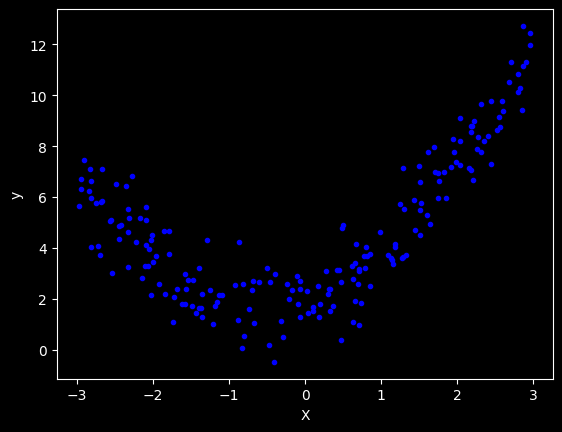

In [7]:
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LinearRegression

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_preds = lr.predict(X_test)

In [14]:
from sklearn.metrics import r2_score

r2_score(y_test, y_preds)

0.249688757884581

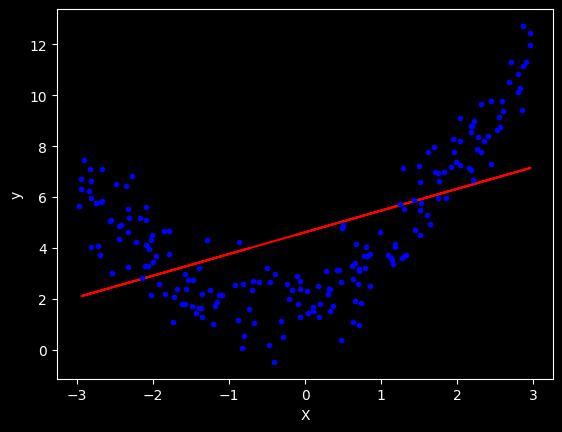

In [15]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Applying Polynomial Regression

In [17]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2,include_bias=True)

In [18]:
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [19]:
print(X_train[0])
print(X_train_trans[0])

[-0.09803483]
[ 1.         -0.09803483  0.00961083]


In [20]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = lr.predict(X_test_trans)

In [22]:
r2_score(y_test,y_pred)

0.8291291624510184

In [23]:
print(lr.coef_)
print(lr.intercept_)


[[0.         0.89289081 0.83073729]]
[2.0287572]


In [25]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

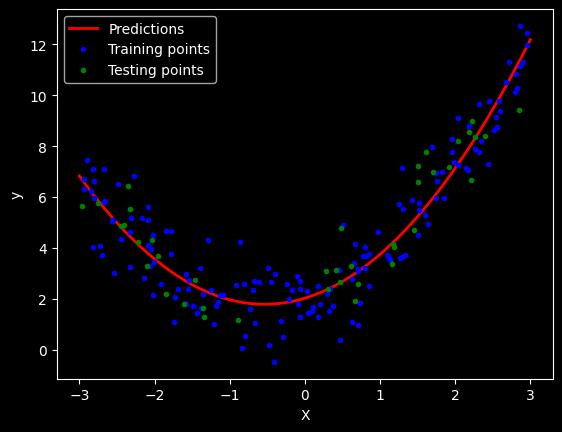

In [26]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()